In [ ]:
# ================================
# 1. Imports
# ================================
import pandas as pd
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import QuantileLoss
import torch


In [24]:
# ================================
# 2. Load Data
# ================================
df = pd.read_csv("dataset/df.csv")


# ================================

In [26]:
df

,Unnamed: 0,date,store,item,sales,is_holiday
0,1,2013-01-01,1,1,13,1
1,2,2013-01-02,1,1,11,0
2,3,2013-01-03,1,1,14,0
3,4,2013-01-04,1,1,13,0
4,5,2013-01-05,1,1,10,0
...,...,...,...,...,...,...
73035,73036,2017-12-27,2,20,56,0
73036,73037,2017-12-28,2,20,51,0
73037,73038,2017-12-29,2,20,54,0
73038,73039,2017-12-30,2,20,55,0


In [27]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [28]:

# 3. Create unique_id (VERY IMPORTANT)
# ================================
df['unique_id'] = df['store'].astype(str) + "_" + df['item'].astype(str)

# Rename columns to NeuralForecast format
df = df.rename(columns={
    'date': 'ds',
    'sales': 'y'
})


In [29]:

# ================================
# 4. Sort data
# ================================
df = df.sort_values(['unique_id', 'ds'])


In [30]:
# ================================
# 5. Train-Test Split (last 90 days)
# ================================
horizon = 90

def split_train_test(df, horizon):
    train_list = []
    test_list = []
    
    for uid, group in df.groupby('unique_id'):
        train_list.append(group.iloc[:-horizon])
        test_list.append(group.iloc[-horizon:])
    
    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df  = pd.concat(test_list).reset_index(drop=True)
    
    return train_df, test_df

train_df, test_df = split_train_test(df, horizon)


In [49]:
# ================================
# 6. Define NHITS Model (Probabilistic)
# ================================
model = NHITS(
    h=horizon,
    input_size=150,   # 1 year lookback
    loss=QuantileLoss(torch.Tensor([0.1, 0.5, 0.9])),
    
    # Architecture tuning
    max_steps=500,
    learning_rate=1e-3,
    
    # Exogenous variables
    futr_exog_list=['is_holiday'],
)

Seed set to 1


In [50]:

# ================================
# 7. Initialize NeuralForecast
# ================================
nf = NeuralForecast(
    models=[model],
    freq='D'
)


In [51]:
train_df

,Unnamed: 0,ds,store,item,y,is_holiday,unique_id
0,1,2013-01-01,1,1,13,1,1_1
1,2,2013-01-02,1,1,11,0,1_1
2,3,2013-01-03,1,1,14,0,1_1
3,4,2013-01-04,1,1,13,0,1_1
4,5,2013-01-05,1,1,10,0,1_1
...,...,...,...,...,...,...,...
69435,32774,2017-09-28,2,9,77,0,2_9
69436,32775,2017-09-29,2,9,93,1,2_9
69437,32776,2017-09-30,2,9,79,0,2_9
69438,32777,2017-10-01,2,9,71,0,2_9


In [52]:

# ================================
# 8. Fit Model
# ================================
nf.fit(df=train_df)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | QuantileLoss  | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.1 M  | train | 0    
---------------------------------------------------------------
3.1 M     Trainable params
0         Non-trainable params
3.1 M     Total params
12.305    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\anconda\envs\python_ds11\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


In [53]:
# ================================
# 9. Prepare Future Data (VERY IMPORTANT)
# ================================
# NeuralForecast needs future exogenous values

future_df = test_df[['unique_id', 'ds', 'is_holiday']]


In [54]:
# ================================
# 10. Predict
# ================================
forecasts = nf.predict(futr_df=future_df)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
d:\anconda\envs\python_ds11\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [55]:
# ================================
# 11. Merge Predictions with Actuals
# ================================
results = forecasts.merge(
    test_df[['unique_id', 'ds', 'y']],
    on=['unique_id', 'ds'],
    how='left'
)

# ================================
# 12. Output
# ================================
print(results.head())

  unique_id         ds  NHITS_qltensor([0.1000, 0.5000, 0.9000])   y
0       1_1 2017-10-03                                 19.241556  18
1       1_1 2017-10-04                                 19.466923  15
2       1_1 2017-10-05                                 21.047928  20
3       1_1 2017-10-06                                 22.349405  19
4       1_1 2017-10-07                                 23.959925  22


In [56]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = results['y']
y_pred = results['NHITS_qltensor([0.1000, 0.5000, 0.9000])']

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.4f}")

RMSE: 9.06
MAE: 6.99
MAPE: 13.56%
R2: 0.9149


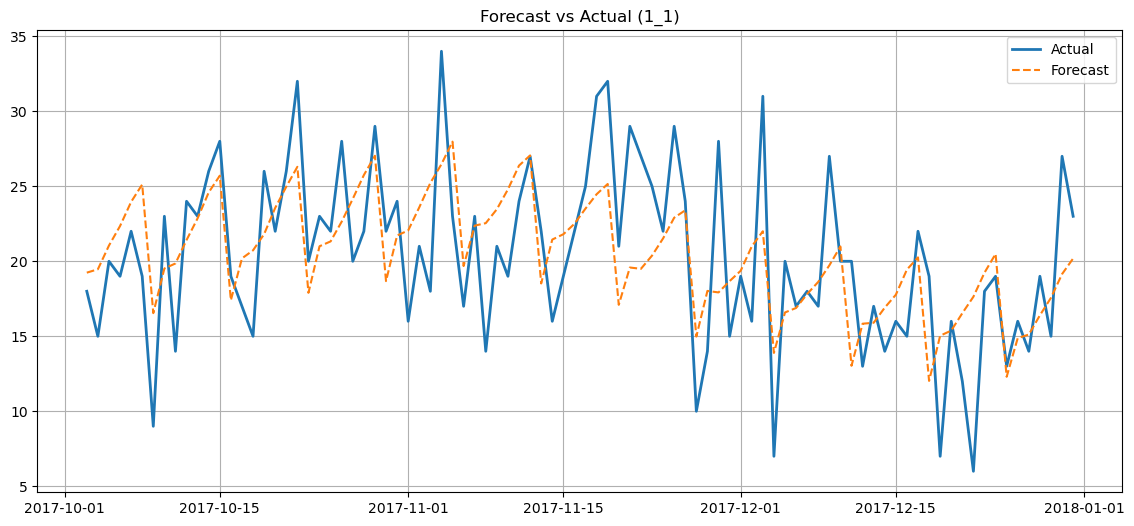

In [58]:
import matplotlib.pyplot as plt

sample_id = results['unique_id'].iloc[0]
plot_df = results[results['unique_id'] == sample_id].sort_values('ds')

plt.figure(figsize=(14,6))

plt.plot(plot_df['ds'], plot_df['y'], label='Actual', linewidth=2)
plt.plot(plot_df['ds'], plot_df['NHITS_qltensor([0.1000, 0.5000, 0.9000])'],
         label='Forecast', linestyle='--')

plt.title(f"Forecast vs Actual ({sample_id})")
plt.legend()
plt.grid(True)
plt.show()